### 4.1.3数据可视化实例


In [ ]:
'''
PassengerId：乘客唯一标识 ID
Survived：是否幸存（0 = 未幸存，1 = 幸存）—— 目标变量
Pclass：客舱等级（1 = 一等舱，2 = 二等舱，3 = 三等舱）
Name：乘客姓名
Sex：性别（male/female）
Age：年龄
SibSp：同船的兄弟姐妹 / 配偶数量
Parch：同船的父母 / 子女数量
Ticket：船票编号
Fare：船票费用
Cabin：客舱编号
Embarked：登船港口（C = 瑟堡，Q = 皇后镇，S = 南安普顿）
'''


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

data_1 = pd.read_csv('./Titanic-Dataset.csv')
print(data_1.columns)

- 也可以用pandas的describe函数快速汇总统计

In [ ]:
data_1['Age'].describe()        # 统计Age列的基本信息

- 使用sns自带的图像函数获得可视化数据

In [ ]:
sns.displot(data_1['Age'].dropna()) # 绘制Age列的分布图,去掉缺失值

- 绘制箱型图和散点图,观察各个数据之间的关系

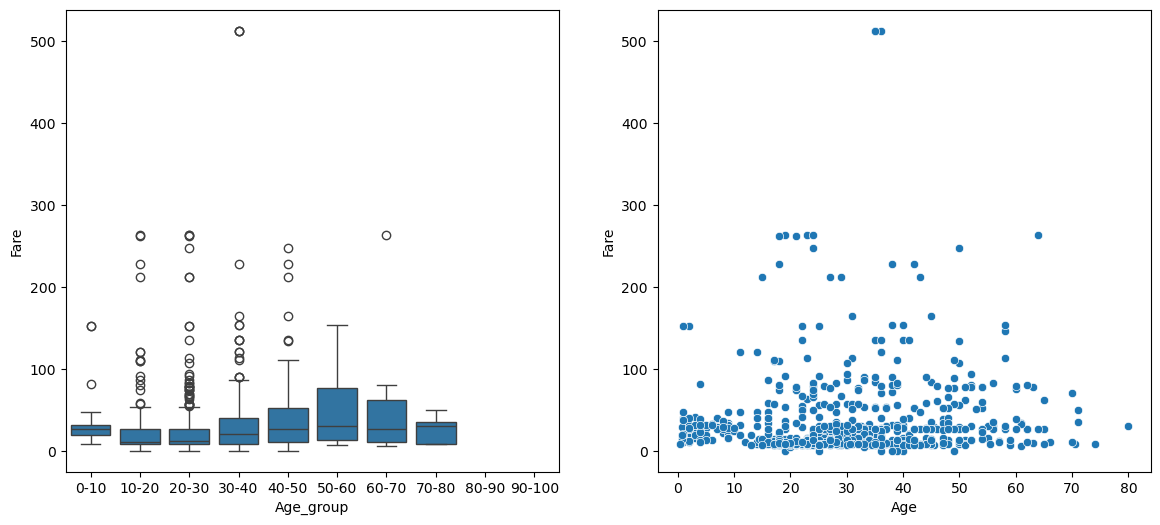

In [19]:

# 1. 对年龄进行分组（每10岁一组）
# 假设原始数据为data_1，先处理可能的缺失值（可选，根据实际数据处理）
data_1['Age_group'] = pd.cut(
    data_1['Age'], 
    bins=range(0, 101, 10),  # 分组区间：0-10,10-20,...,90-100
    labels=['0-10', '10-20', '20-30', '30-40', '40-50', 
            '50-60', '60-70', '70-80', '80-90', '90-100']  # 分组标签
)

data_2 = pd.concat([data_1['Age_group'], data_1['Fare'], data_1['Age']], axis=1) # 选择Age_group和Fare两列数据
f, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 6))
box_fig = sns.boxplot(x='Age_group', y='Fare', data=data_2, ax=ax1)
sca_fig = sns.scatterplot(x='Age', y='Fare', data=data_2, ax=ax2)

plt.show()